In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import random
import math
import time

In [2]:
df = pd.read_csv('historical_data.csv')

X = torch.tensor(df.iloc[:, :48].values, dtype=torch.float32)
target = torch.tensor(df['pred'], dtype=torch.float32)

print(X.shape)
print(target.shape)

torch.Size([10000, 48])
torch.Size([10000])


In [3]:
in_ids = []
in_weights = []
out_ids = []
out_weights = []
final_id = None

for i in range(97):
    p = torch.load(f'pieces/piece_{i}.pth', map_location='cpu', weights_only=True)
    w = p['weight']

    if w.shape == (96, 48):
        in_ids.append(i)
        in_weights.append(p['weight'])
    elif w.shape == (48, 96):
        out_ids.append(i)
        out_weights.append(p['weight'])
    else:
        final_id = i

In [4]:
scores = np.zeros((48, 48))

for i in range(48):
    U_in, S_in, _ = torch.linalg.svd(in_weights[i], full_matrices = False)

    for j in range(48):
        _, S_out, Vt_out = torch.linalg.svd(out_weights[j], full_matrices = False)
        V_out = Vt_out.T

        combined = U_in.T @ V_out
        score = (torch.diag(S_in) @ combined @ torch.diag(S_out)).norm()
        scores[i, j] = score

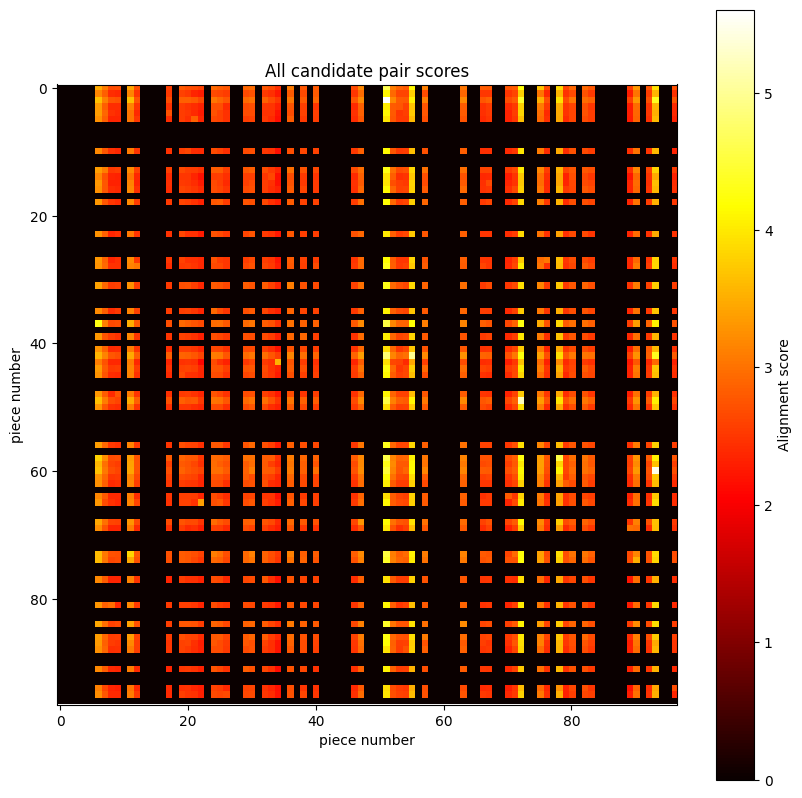

In [5]:
grid1 = np.zeros((97, 97))
for i in range(48):
    for j in range(48):
        grid1[in_ids[i], out_ids[j]] = scores[i, j]

plt.figure(figsize=(10, 10))
plt.imshow(grid1, cmap='hot')
plt.colorbar(label='Alignment score')
plt.xlabel('piece number')
plt.ylabel('piece number')
plt.title('All candidate pair scores')
plt.show()

In [6]:
row_idx, col_idx = linear_sum_assignment(-scores)
matched = np.zeros((48, 48))

for r, c in zip(row_idx, col_idx):
    matched[r, c] = scores[r, c]

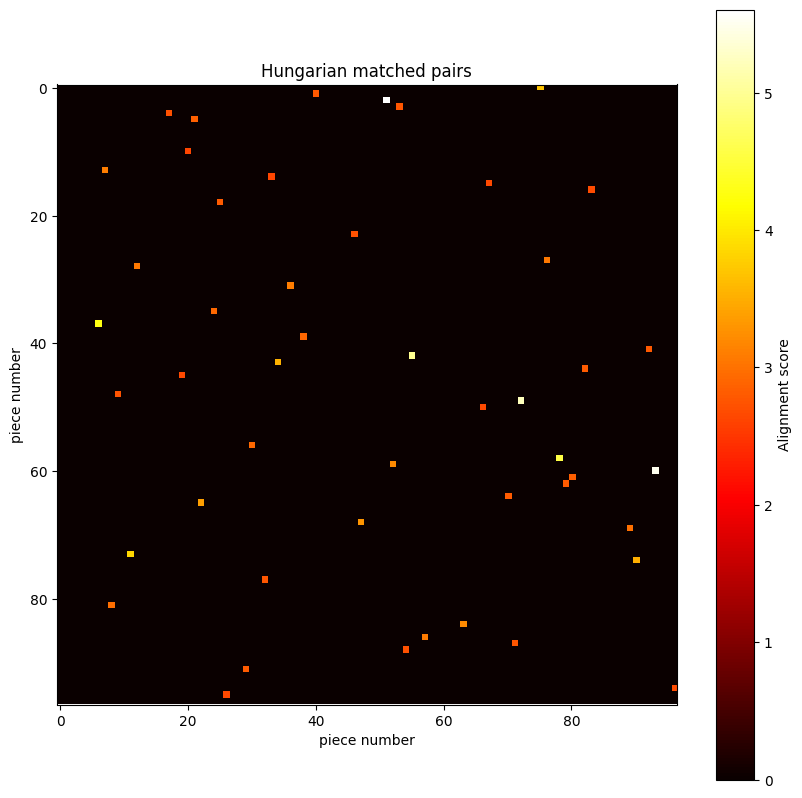

In [7]:
grid2 = np.zeros((97, 97))
for r, c in zip(row_idx, col_idx):
    grid2[in_ids[r], out_ids[c]] = scores[r, c]

plt.figure(figsize=(10, 10))
plt.imshow(grid2, cmap='hot')
plt.colorbar(label='Alignment score')
plt.xlabel('piece number')
plt.ylabel('piece number')
plt.title('Hungarian matched pairs')
plt.show()

In [8]:
blocks = []

for r, c in zip(row_idx, col_idx):
    in_p = torch.load(f'pieces/piece_{in_ids[r]}.pth', map_location='cpu', weights_only=True)
    out_p = torch.load(f'pieces/piece_{out_ids[c]}.pth', map_location='cpu', weights_only=True)

    blocks.append({
        'in_w': in_p['weight'],
        'in_b': in_p['bias'],
        'out_w': out_p['weight'],
        'out_b': out_p['bias'],
    })

final_p = torch.load(f'pieces/piece_{final_id}.pth', map_location='cpu', weights_only=True)
final_w = final_p['weight']
final_b = final_p['bias']

In [9]:
@torch.no_grad()
def evaluate(order):
    x = X.clone()
    for i in order:
        b = blocks[i]
        h = F.linear(x, b['in_w'], b['in_b'])
        h = F.relu(h)
        delta = F.linear(h, b['out_w'], b['out_b'])
        x = x + delta
    out = F.linear(x, final_w, final_b).squeeze()
    return ((out - target) ** 2).mean().item()

In [10]:
norms = [(blocks[i]['out_w'].norm().item(), i) for i in range(48)]
norms.sort()
order = [idx for _, idx in norms]
mse = evaluate(order)
print(f"Start MSE: {mse:.6f}")

Start MSE: 0.075851


In [11]:
for rnd in range(20):
    swaps = 0

    for i in range(47):
        order[i], order[i+1] = order[i+1], order[i]
        new_mse = evaluate(order)
        if new_mse < mse:
            mse = new_mse
            swaps += 1
        else:
            order[i], order[i+1] = order[i+1], order[i]
    
    for i in range(46, -1, -1):
        order[i], order[i+1] = order[i+1], order[i]
        new_mse = evaluate(order)
        if new_mse < mse:
            mse = new_mse
            swaps += 1
        else:
            order[i], order[i+1] = order[i+1], order[i]
    
    print(f"Round {rnd+1:2d}: {swaps:3d} swaps, MSE = {mse:.8f}")
    if swaps == 0:
        print("Converged!")
        break

for gap in range(2, 6):
    for i in range(48 - gap):
        order[i], order[i+gap] = order[i+gap], order[i]
        new_mse = evaluate(order)
        if new_mse < mse:
            mse = new_mse
            print(f"Gap {gap} swap at {i}: MSE = {mse:.8f}")
        else:
            order[i], order[i+gap] = order[i+gap], order[i]

print(f"\nFinal MSE: {mse:.8f}")

Round  1:  55 swaps, MSE = 0.00206093
Round  2:  10 swaps, MSE = 0.00044882
Round  3:   3 swaps, MSE = 0.00000000
Round  4:   0 swaps, MSE = 0.00000000
Converged!

Final MSE: 0.00000000


In [12]:
flat = []

for idx in order:
    flat.append(in_ids[row_idx[idx]])   
    flat.append(out_ids[col_idx[idx]]) 
flat.append(final_id)                

print(','.join(str(x) for x in flat))

43,34,65,22,69,89,28,12,27,76,81,8,5,21,62,79,64,70,94,96,4,17,48,9,23,46,14,33,95,26,50,66,1,40,15,67,41,92,16,83,77,32,10,20,3,53,45,19,87,71,88,54,39,38,18,25,56,30,91,29,44,82,35,24,61,80,86,57,31,36,13,7,59,52,68,47,84,63,74,90,0,75,73,11,37,6,58,78,42,55,49,72,2,51,60,93,85
